In [1]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
import matplotlib
import matplotlib.pyplot as plt       # import pyplot library
from torch.autograd import Variable   # variable from numpy to torch

seed = 20
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [3]:
epochs        = 5000    # number of training epochs
col_p         = 1000     # number of collocation points
col_bc        = 200
hidden_size   = 45       # number of neurons per hidden layer
learning_rate = 0.0001   # learning rate parameter

E   = 21e9              # Pa    (Young Modulus)
miu = 0.3               # adim. (Poisson's ratio)
a   = 4                 # m     (Horizontal plate dimension)
b   = 4                 # m     (Vertical plate dimension)
t   = 0.05              # m     (Plate thickness)
u   = 0.5               # m     (Loaded area width)
v   = 1                 # m     (Loaded area height)
e   = 1.25              # m     (Loaded area center)
n   = 1.5               # m     (Loaded area center)

def q(x,y):
    xboundary_1 = e - u/2
    xboundary_2 = e + u/2
    yboundary_1 = n - v/2
    yboundary_2 = n + v/2

    for i in range(col_p):
        if (x[i] >= xboundary_1 and x[i] <= xboundary_2) and (y[i] >= yboundary_1 and y[i] <= yboundary_2):
            return -10_000    # N/m2  (Distributed load q)
        else:
            return 0

D = E*(t**3)/(12*(1-miu**2))  # (Flexural stiffness of the plate)

u   = 0.5               # m     (Distributed load horizontal dimension)
v   = 1                 # m     (Distributed load vertical dimension)
e,n = 1.25,1.5          # m     (Center of loaded area)

class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.fc5 = nn.Linear(hidden_size, hidden_size)
        self.fc6 = nn.Linear(hidden_size, hidden_size)
        self.fc7 = nn.Linear(hidden_size, 1)

    def forward(self,x,y):
        # Concatenate the input features into a single tensor
        inputs = torch.cat([x, y], axis=1)
        w = torch.tanh(self.fc1(inputs))
        w = torch.tanh(self.fc2(w))
        w = torch.tanh(self.fc3(w))
        w = torch.tanh(self.fc4(w))
        w = torch.tanh(self.fc5(w))
        w = torch.tanh(self.fc6(w))
        w = self.fc7(w)
        return w

In [4]:
### (2) Model
# Create the neural network and move it to the GPU if available
NN = NN().to(device)                                       # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()                     # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters(), lr=learning_rate)  # Adam optimizer for parameter updating

In [5]:
## PDE as loss function.
def f(x,y,NN):    
    w = NN(x,y) # the dependent variable w is given by the network based on independent variables x and y
    ## Based on our f = d4w/dx4 + 2*d4w/dx2*dy2 + d4w/dy4 - q/D, we need d4w/dx4, d4w/dx2*dy2 and d4w/dy4
   
    # d4w/dx4
    dwdx   = torch.autograd.grad(w.sum(),     x,create_graph=True)[0]  # dw/dx
    d2wdx2 = torch.autograd.grad(dwdx.sum(),  x,create_graph=True)[0]  # d2w/dx2
    d3wdx3 = torch.autograd.grad(d2wdx2.sum(),x,create_graph=True)[0]  # d3w/dx3
    d4wdx4 = torch.autograd.grad(d3wdx3.sum(),x,create_graph=True)[0]  # d4w/dx4
    
    # d4w/dx4
    dwdy   = torch.autograd.grad(w.sum(),     y,create_graph=True)[0]  # dw/dy
    d2wdy2 = torch.autograd.grad(dwdy.sum(),  y,create_graph=True)[0]  # d2w/dy2
    d3wdy3 = torch.autograd.grad(d2wdy2.sum(),y,create_graph=True)[0]  # d3w/dy3
    d4wdy4 = torch.autograd.grad(d3wdy3.sum(),y,create_graph=True)[0]  # d4w/dy4
    
    # d4w/dx2*dy2
    d3wdx2dy  = torch.autograd.grad(d2wdx2.sum(),  y,create_graph=True)[0]  # d3w/dx2*dy
    d4wdx2dy2 = torch.autograd.grad(d3wdx2dy.sum(),y,create_graph=True)[0]  # d3w/dx2*dy2
    
    pde  = d4wdx4 + 2*d4wdx2dy2 + d4wdy4 - q(x,y)/D     
    return pde

In [6]:
## Data from Boundary Conditions
## BC gives us datapoints for training
## We will find out w(x,y) for x in range [0,a] and y in range [0,b]

#################################### 1.1. y=0, w(x,0)=0 ####################################
x_bc11         = np.linspace(0,a,col_bc).reshape(col_bc,1)
y_bc11         = np.zeros((col_bc,1))  # y      value for the boundary condition
w_bc11         = np.zeros((col_bc,1))  # w      value for the boundary condition

pt_x_bc11      = Variable(torch.from_numpy(x_bc11).float(),      requires_grad=True).to(device)
pt_y_bc11      = Variable(torch.from_numpy(y_bc11).float(),      requires_grad=True).to(device)
pt_w_bc11      = Variable(torch.from_numpy(w_bc11).float(),      requires_grad=False).to(device)

#################################### 1.2. y=0, d2wdy2=0 ####################################
x_bc12         = np.linspace(0,a,col_bc).reshape(col_bc,1)
y_bc12         = np.zeros((col_bc,1))  # y      value for the boundary condition
d2wdy2_bc12    = np.zeros((col_bc,1))  # d2wdy2 value for the boundary condition

pt_x_bc12      = Variable(torch.from_numpy(x_bc12).float(),      requires_grad=True).to(device)
pt_y_bc12      = Variable(torch.from_numpy(y_bc12).float(),      requires_grad=True).to(device)
pt_d2wdy2_bc12 = Variable(torch.from_numpy(d2wdy2_bc12).float(), requires_grad=False).to(device)

#################################### 2.1. y=b, w(x,b)=0 ####################################
x_bc21         = np.linspace(0,a,col_bc).reshape(col_bc,1)
y_bc21         = b*np.ones((col_bc,1)) # y      value for the boundary condition
w_bc21         = np.zeros((col_bc,1))  # w      value for the boundary condition

pt_x_bc21      = Variable(torch.from_numpy(x_bc21).float(),      requires_grad=True).to(device)
pt_y_bc21      = Variable(torch.from_numpy(y_bc21).float(),      requires_grad=True).to(device)
pt_w_bc21      = Variable(torch.from_numpy(w_bc21).float(),      requires_grad=False).to(device)

#################################### 2.2. y=b, d2wdy2=0 ####################################
x_bc22         = np.linspace(0,a,col_bc).reshape(col_bc,1)
y_bc22         = b*np.ones((col_bc,1)) # y      value for the boundary condition
d2wdy2_bc22    = np.zeros((col_bc,1))  # d2wdy2 value for the boundary condition

pt_x_bc22      = Variable(torch.from_numpy(x_bc22).float(),      requires_grad=True).to(device)
pt_y_bc22      = Variable(torch.from_numpy(y_bc22).float(),      requires_grad=True).to(device)
pt_d2wdy2_bc22 = Variable(torch.from_numpy(d2wdy2_bc22).float(), requires_grad=False).to(device)

#################################### 3.1. x=0, w(0,y)=0 ####################################
x_bc31         = np.zeros((col_bc,1))  # x      value for the boundary condition
y_bc31         = np.linspace(0,b,col_bc).reshape(col_bc,1)
w_bc31         = np.zeros((col_bc,1))  # w      value for the boundary condition

pt_x_bc31      = Variable(torch.from_numpy(x_bc31).float(),      requires_grad=True).to(device)
pt_y_bc31      = Variable(torch.from_numpy(y_bc31).float(),      requires_grad=True).to(device)
pt_w_bc31      = Variable(torch.from_numpy(w_bc31).float(),      requires_grad=False).to(device)

#################################### 3.2. x=0, d2wdx2=0 ####################################
x_bc32         = np.zeros((col_bc,1))  # x      value for the boundary condition
y_bc32         = np.linspace(0,b,col_bc).reshape(col_bc,1)
d2wdx2_bc32    = np.zeros((col_bc,1))  # d2wdx2 value for the boundary condition

pt_x_bc32      = Variable(torch.from_numpy(x_bc32).float(),      requires_grad=True).to(device)
pt_y_bc32      = Variable(torch.from_numpy(y_bc32).float(),      requires_grad=True).to(device)
pt_d2wdx2_bc32 = Variable(torch.from_numpy(d2wdx2_bc32).float(), requires_grad=False).to(device)

#################################### 4.1. x=a, w(a,y)=0 ####################################
x_bc41         = a*np.ones((col_bc,1)) # x      value for the boundary condition
y_bc41         = np.linspace(0,b,col_bc).reshape(col_bc,1)
w_bc41         = np.zeros((col_bc,1))  # w      value for the boundary condition

pt_x_bc41      = Variable(torch.from_numpy(x_bc41).float(),      requires_grad=True).to(device)
pt_y_bc41      = Variable(torch.from_numpy(y_bc41).float(),      requires_grad=True).to(device)
pt_w_bc41      = Variable(torch.from_numpy(w_bc41).float(),      requires_grad=False).to(device)

#################################### 4.2. x=a, d2wdx2=0 ####################################
x_bc42         = a*np.ones((col_bc,1)) # x      value for the boundary condition
y_bc42         = np.linspace(0,b,col_bc).reshape(col_bc,1)
d2wdx2_bc42    = np.zeros((col_bc,1))  # d2wdx2 value for the boundary condition

pt_x_bc42      = Variable(torch.from_numpy(x_bc42).float(),      requires_grad=True).to(device)
pt_y_bc42      = Variable(torch.from_numpy(y_bc42).float(),      requires_grad=True).to(device)
pt_d2wdx2_bc42 = Variable(torch.from_numpy(d2wdx2_bc42).float(), requires_grad=False).to(device)

In [7]:
### (3) Training / Fitting

Loss_bc11  = []
Loss_bc12  = []
Loss_bc21  = []
Loss_bc22  = []
Loss_bc31  = []
Loss_bc32  = []
Loss_bc41  = []
Loss_bc42  = []
Loss_f     = []
Loss_track = []           # Initialize empty list for gathering loss values

NN.train()

for epoch in range(epochs):
    
    if epoch < (epochs/2):
        learning_rate = learning_rate
        nuevo_lr = learning_rate/3
    else:
        learning_rate = nuevo_lr
    
    optimizer.zero_grad() # To make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.1.      
    NN_bc11_out  = NN(pt_x_bc11,pt_y_bc11) # output NN(x,y) --> w
    mse_u11      = mse_cost_function(NN_bc11_out, pt_w_bc11)
    
    # BC 1.2.  
    NN_bc12_out  = NN(pt_x_bc12,pt_y_bc12) # output NN(x,y) --> w
    dNNdx_bc12   = torch.autograd.grad(NN_bc12_out.sum(),pt_y_bc12,create_graph=True)[0]
    d2NNdx2_bc12 = torch.autograd.grad(dNNdx_bc12.sum(),pt_y_bc12,create_graph=True)[0]
    mse_u12      = mse_cost_function(d2NNdx2_bc12, pt_d2wdy2_bc12)

    # BC 2.1.      
    NN_bc21_out  = NN(pt_x_bc21,pt_y_bc21) # output NN(x,y) --> w
    mse_u21      = mse_cost_function(NN_bc21_out, pt_w_bc21)
    
    # BC 2.2.  
    NN_bc22_out  = NN(pt_x_bc22,pt_y_bc22) # output NN(x,y) --> w
    dNNdx_bc22   = torch.autograd.grad(NN_bc22_out.sum(),pt_y_bc22,create_graph=True)[0]
    d2NNdx2_bc22 = torch.autograd.grad(dNNdx_bc22.sum(),pt_y_bc22,create_graph=True)[0]
    mse_u22      = mse_cost_function(d2NNdx2_bc22, pt_d2wdy2_bc22)
    
    # BC 3.1.      
    NN_bc31_out  = NN(pt_x_bc31,pt_y_bc31) # output NN(x,y) --> w
    mse_u31      = mse_cost_function(NN_bc31_out, pt_w_bc31)
    
    # BC 3.2.  
    NN_bc32_out  = NN(pt_x_bc32,pt_y_bc32) # output NN(x,y) --> w
    dNNdx_bc32   = torch.autograd.grad(NN_bc32_out.sum(),pt_x_bc32,create_graph=True)[0]
    d2NNdx2_bc32 = torch.autograd.grad(dNNdx_bc32.sum(),pt_x_bc32,create_graph=True)[0]
    mse_u32      = mse_cost_function(d2NNdx2_bc32, pt_d2wdx2_bc32)
    
    # BC 4.1.      
    NN_bc41_out  = NN(pt_x_bc41,pt_y_bc41) # output NN(x,y) --> w
    mse_u41      = mse_cost_function(NN_bc41_out, pt_w_bc41)
    
    # BC 4.2.  
    NN_bc42_out  = NN(pt_x_bc42,pt_y_bc42) # output NN(x,y) --> w
    dNNdx_bc42   = torch.autograd.grad(NN_bc42_out.sum(),pt_x_bc42,create_graph=True)[0]
    d2NNdx2_bc42 = torch.autograd.grad(dNNdx_bc42.sum(),pt_x_bc42,create_graph=True)[0]
    mse_u42      = mse_cost_function(d2NNdx2_bc42, pt_d2wdx2_bc42)
    
    # Loss based on PDE
    #x_col       = np.random.rand(col_p,1)   
    x_col        = np.random.uniform(low=0.1,high=a-0.1,size=(col_p,1))
    y_col        = np.random.uniform(low=0.1,high=b-0.1,size=(col_p,1))
    all_zeros    = np.zeros((col_p,1))
    
    pt_x_col     = Variable(torch.from_numpy(x_col).float(), requires_grad=True).to(device)
    pt_y_col     = Variable(torch.from_numpy(y_col).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out        = f(pt_x_col,pt_y_col,NN)                # Output of f(x)
    mse_f        = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u11 + mse_u12 + mse_u21 + mse_u22 + mse_u31 + mse_u32 + mse_u41 + mse_u42 + mse_f
    
    loss.backward()  # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to: theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_bc11 = mse_u11.data.cpu().numpy()
    loss_bc12 = mse_u12.data.cpu().numpy()
    loss_bc21 = mse_u21.data.cpu().numpy()
    loss_bc22 = mse_u22.data.cpu().numpy()
    loss_bc31 = mse_u31.data.cpu().numpy()
    loss_bc32 = mse_u32.data.cpu().numpy()
    loss_bc41 = mse_u41.data.cpu().numpy()
    loss_bc42 = mse_u42.data.cpu().numpy()
    loss_f    =  mse_f.data.cpu().numpy()
    loss_np   =   loss.data.cpu().numpy()          # Torch tensors to Numpy
    
    Loss_bc11   = np.append(Loss_bc11, loss_bc11)
    Loss_bc12   = np.append(Loss_bc12, loss_bc12)
    Loss_bc21   = np.append(Loss_bc21, loss_bc21)
    Loss_bc22   = np.append(Loss_bc22, loss_bc22)
    Loss_bc31   = np.append(Loss_bc31, loss_bc31)
    Loss_bc32   = np.append(Loss_bc32, loss_bc32)
    Loss_bc41   = np.append(Loss_bc41, loss_bc41)
    Loss_bc42   = np.append(Loss_bc42, loss_bc42)
    Loss_f      = np.append(Loss_f,    loss_f)
    Loss_track  = np.append(Loss_track,loss_np)   # Tracking loss values and creating a list
    
    with torch.autograd.no_grad():
        if epoch % 100 == 0: print("Epoch:",epoch,"|| Traning Loss:",
                                   loss.data.item(),"|| lr =",learning_rate) # Print loss every 100 epochs

Epoch: 0 || Traning Loss: 0.07840605080127716 || lr = 0.0001
Epoch: 100 || Traning Loss: 0.0002761273644864559 || lr = 0.0001
Epoch: 200 || Traning Loss: 0.0001208073808811605 || lr = 0.0001
Epoch: 300 || Traning Loss: 5.893928755540401e-05 || lr = 0.0001
Epoch: 400 || Traning Loss: 3.3586158679099753e-05 || lr = 0.0001
Epoch: 500 || Traning Loss: 2.115369716193527e-05 || lr = 0.0001
Epoch: 600 || Traning Loss: 1.4371215002029203e-05 || lr = 0.0001
Epoch: 700 || Traning Loss: 9.837700417847373e-06 || lr = 0.0001
Epoch: 800 || Traning Loss: 7.320315489778295e-06 || lr = 0.0001
Epoch: 900 || Traning Loss: 5.640815288643353e-06 || lr = 0.0001
Epoch: 1000 || Traning Loss: 4.065111170348246e-06 || lr = 0.0001
Epoch: 1100 || Traning Loss: 3.3061000976886135e-06 || lr = 0.0001
Epoch: 1200 || Traning Loss: 2.907024281739723e-06 || lr = 0.0001
Epoch: 1300 || Traning Loss: 0.0016964722890406847 || lr = 0.0001
Epoch: 1400 || Traning Loss: 3.0852434065309353e-06 || lr = 0.0001
Epoch: 1500 || Trani

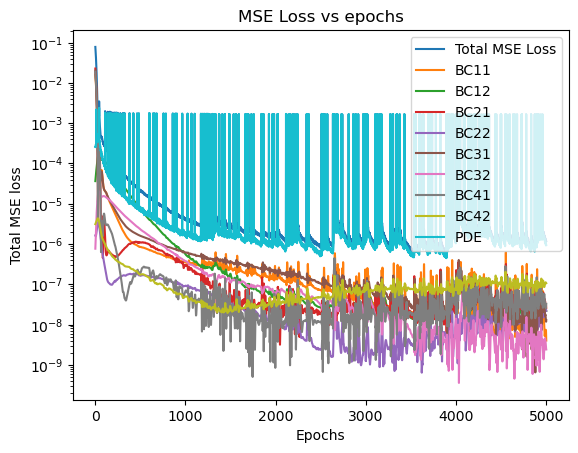

In [8]:
#Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.semilogy(ep,Loss_track)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('Total MSE loss')

plt.semilogy(ep,Loss_bc11)
plt.semilogy(ep,Loss_bc12)
plt.semilogy(ep,Loss_bc21)
plt.semilogy(ep,Loss_bc22)
plt.semilogy(ep,Loss_bc31)
plt.semilogy(ep,Loss_bc32)
plt.semilogy(ep,Loss_bc41)
plt.semilogy(ep,Loss_bc42)
plt.semilogy(ep,Loss_f)

plt.legend(['Total MSE Loss','BC11','BC12','BC21','BC22','BC31','BC32','BC41','BC42','PDE'])
plt.show()

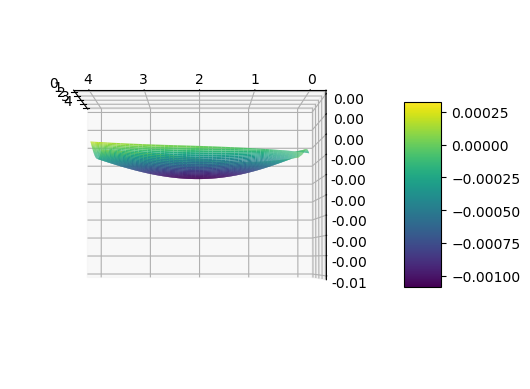

In [25]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.animation import FuncAnimation

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x    = np.arange(0.0, a, 0.01)
y    = np.arange(0.0, b, 0.01)
X,Y  = np.meshgrid(x,y)
x    = np.ravel(X).reshape(-1,1)
y    = np.ravel(Y).reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y).float(), requires_grad=True).to(device)
pt_w = NN(pt_x,pt_y)
w    = pt_w.data.cpu().numpy()
W    = w.reshape(X.shape)

surf = ax.plot_surface(X,Y,W,cmap=cm.viridis)

ax.set_zlim(-0.005, 0.002) 
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))
ax.view_init(-2, 180)

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()